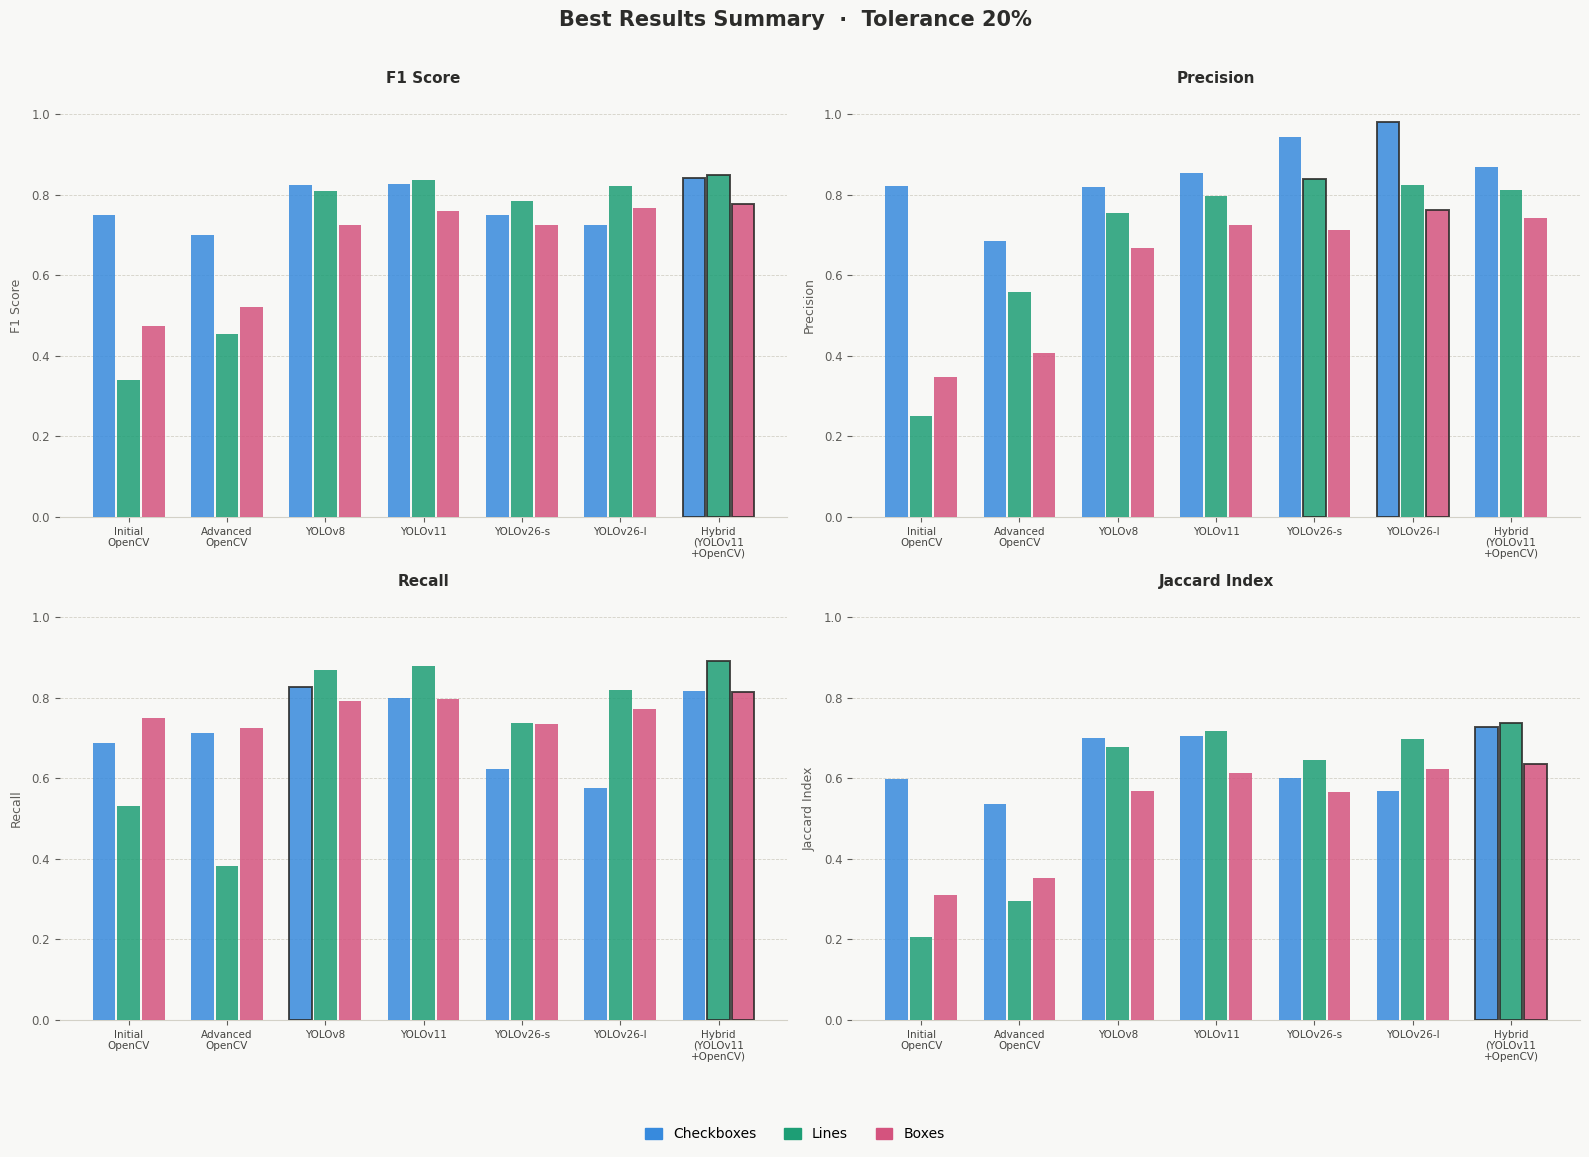

Saved → best_results_summary.png


In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

DATA = {
    "Initial\nOpenCV":  {"Checkboxes": {"precision":0.822,"recall":0.687,"f1":0.749,"jaccard":0.598},
                         "Lines":      {"precision":0.251,"recall":0.530,"f1":0.341,"jaccard":0.205},
                         "Boxes":      {"precision":0.347,"recall":0.750,"f1":0.474,"jaccard":0.311}},
    "Advanced\nOpenCV": {"Checkboxes": {"precision":0.685,"recall":0.713,"f1":0.699,"jaccard":0.537},
                         "Lines":      {"precision":0.559,"recall":0.382,"f1":0.454,"jaccard":0.294},
                         "Boxes":      {"precision":0.406,"recall":0.724,"f1":0.520,"jaccard":0.351}},
    "YOLOv8":           {"Checkboxes": {"precision":0.820,"recall":0.826,"f1":0.823,"jaccard":0.699},
                         "Lines":      {"precision":0.755,"recall":0.869,"f1":0.808,"jaccard":0.677},
                         "Boxes":      {"precision":0.667,"recall":0.793,"f1":0.724,"jaccard":0.568}},
    "YOLOv11":          {"Checkboxes": {"precision":0.855,"recall":0.800,"f1":0.827,"jaccard":0.705},
                         "Lines":      {"precision":0.797,"recall":0.878,"f1":0.836,"jaccard":0.718},
                         "Boxes":      {"precision":0.726,"recall":0.798,"f1":0.760,"jaccard":0.613}},
    "YOLOv26-s":        {"Checkboxes": {"precision":0.944,"recall":0.622,"f1":0.750,"jaccard":0.600},
                         "Lines":      {"precision":0.839,"recall":0.737,"f1":0.785,"jaccard":0.646},
                         "Boxes":      {"precision":0.713,"recall":0.734,"f1":0.724,"jaccard":0.567}},
    "YOLOv26-l":        {"Checkboxes": {"precision":0.981,"recall":0.575,"f1":0.725,"jaccard":0.569},
                         "Lines":      {"precision":0.825,"recall":0.818,"f1":0.821,"jaccard":0.697},
                         "Boxes":      {"precision":0.761,"recall":0.773,"f1":0.767,"jaccard":0.622}},
    "Hybrid\n(YOLOv11\n+OpenCV)": {"Checkboxes": {"precision":0.869,"recall":0.817,"f1":0.842,"jaccard":0.727},
                                    "Lines":      {"precision":0.812,"recall":0.891,"f1":0.850,"jaccard":0.738},
                                    "Boxes":      {"precision":0.743,"recall":0.814,"f1":0.777,"jaccard":0.636}},
}

MODELS  = list(DATA.keys())
CLASSES = ["Checkboxes", "Lines", "Boxes"]
METRICS = ["f1", "precision", "recall", "jaccard"]
METRIC_LABELS = {"f1": "F1 Score", "precision": "Precision", "recall": "Recall", "jaccard": "Jaccard Index"}

COLORS = {"Checkboxes": "#378ADD", "Lines": "#1D9E75", "Boxes": "#D4537E"}

fig, axes = plt.subplots(2, 2, figsize=(16, 11), facecolor="#f8f8f6")
fig.suptitle("Best Results Summary  ·  Tolerance 20%",
             fontsize=15, fontweight="bold", color="#2C2C2A", y=1.01)

x = np.arange(len(MODELS))
width = 0.25
offsets = [-width, 0, width]

for ax, metric in zip(axes.flat, METRICS):
    ax.set_facecolor("#f8f8f6")
    ax.spines[["top","right","left"]].set_visible(False)
    ax.spines["bottom"].set_color("#D3D1C7")
    ax.tick_params(colors="#5F5E5A", labelsize=8.5)
    ax.set_ylim(0, 1.05)
    ax.set_yticks(np.arange(0, 1.1, 0.2))
    ax.yaxis.grid(True, color="#D3D1C7", linewidth=0.6, linestyle="--")
    ax.set_axisbelow(True)

    for i, (cls, off) in enumerate(zip(CLASSES, offsets)):
        vals = [DATA[m][cls][metric] for m in MODELS]
        bars = ax.bar(x + off, vals, width=width - 0.02,
                      color=COLORS[cls], alpha=0.85, zorder=3,
                      linewidth=0)
        # Highlight the best bar per class with a darker edge
        best_idx = int(np.argmax(vals))
        bars[best_idx].set_edgecolor("#2C2C2A")
        bars[best_idx].set_linewidth(1.4)

    ax.set_xticks(x)
    ax.set_xticklabels(MODELS, fontsize=7.5, color="#444441", linespacing=1.15)
    ax.set_ylabel(METRIC_LABELS[metric], fontsize=9, color="#5F5E5A", labelpad=6)
    ax.set_title(METRIC_LABELS[metric], fontsize=11, fontweight="bold",
                 color="#2C2C2A", pad=8)

# Shared legend
patches = [mpatches.Patch(color=COLORS[c], label=c) for c in CLASSES]
fig.legend(handles=patches, loc="lower center", ncol=3,
           fontsize=10, frameon=False,
           bbox_to_anchor=(0.5, -0.03),
           handlelength=1.2, handleheight=0.9)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig("best_results_summary.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Saved → best_results_summary.png")